<a href="https://colab.research.google.com/github/Harshil1335/Solar-Power-Prediction-ML/blob/main/Movie_Review_Sentiment_Analysis_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# Use the python engine and skip bad lines to handle the EOF/quoting error
df = pd.read_csv('IMDB Dataset.csv', engine='python', on_bad_lines='skip')

print(df.head())
print(df['sentiment'].value_counts())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
df = df.sample(2000, random_state=42)  # Reduced to 2k samples for faster execution

In [ ]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [ ]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    return text

df['review'] = df['review'].apply(clean_text)

In [ ]:
X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM": SVC()
}

results = {}

In [ ]:
from sklearn.ensemble import VotingClassifier

# Define models again (include hybrid)
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM": SVC(probability=True),  # important for hybrid
}

# Hybrid Model (SVM + Logistic)
hybrid_model = VotingClassifier(
    estimators=[
        ('svm', SVC(probability=True)),
        ('lr', LogisticRegression(max_iter=200))
    ],
    voting='soft'
)

models["Hybrid (SVM+LR)"] = hybrid_model

# Reset results
results = {}

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    specificity = TN / (TN + FP)
    sensitivity = TP / (TP + FN)
    fpr = FP / (FP + TN)
    fnr = FN / (FN + TP)
    npv = TN / (TN + FN)
    fdr = FP / (FP + TP)

    results[name] = [
        specificity, sensitivity, accuracy, precision,
        fpr, fnr, npv, fdr, f1, mcc
    ]

    print(f"\n{name}")
    print("Specificity:", specificity)
    print("Sensitivity:", sensitivity)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("FPR:", fpr)
    print("FNR:", fnr)
    print("NPV:", npv)
    print("FDR:", fdr)
    print("F1 Score:", f1)
    print("MCC:", mcc)


Naive Bayes
Specificity: 0.9186602870813397
Sensitivity: 0.6649214659685864
Accuracy: 0.7975
Precision: 0.8819444444444444
FPR: 0.08133971291866028
FNR: 0.33507853403141363
NPV: 0.75
FDR: 0.11805555555555555
F1 Score: 0.7582089552238805
MCC: 0.6072818511359042

Logistic Regression
Specificity: 0.84688995215311
Sensitivity: 0.8219895287958116
Accuracy: 0.835
Precision: 0.8306878306878307
FPR: 0.15311004784688995
FNR: 0.17801047120418848
NPV: 0.8388625592417062
FDR: 0.1693121693121693
F1 Score: 0.8263157894736842
MCC: 0.6692148513633097

SVM
Specificity: 0.84688995215311
Sensitivity: 0.8272251308900523
Accuracy: 0.8375
Precision: 0.8315789473684211
FPR: 0.15311004784688995
FNR: 0.17277486910994763
NPV: 0.8428571428571429
FDR: 0.16842105263157894
F1 Score: 0.8293963254593176
MCC: 0.6742755675313409

Hybrid (SVM+LR)
Specificity: 0.84688995215311
Sensitivity: 0.8272251308900523
Accuracy: 0.8375
Precision: 0.8315789473684211
FPR: 0.15311004784688995
FNR: 0.17277486910994763
NPV: 0.842857142

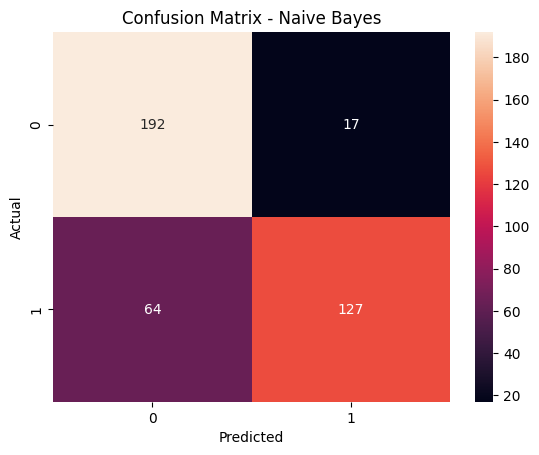

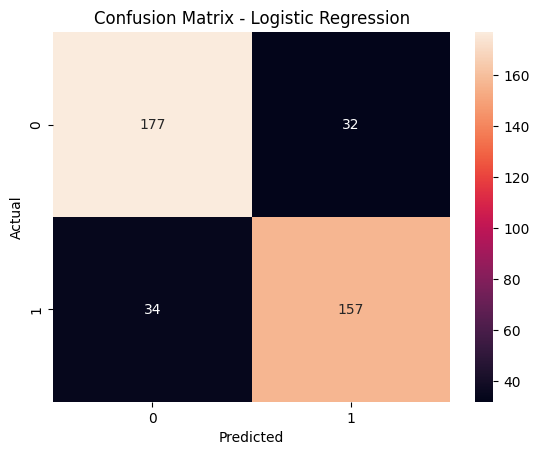

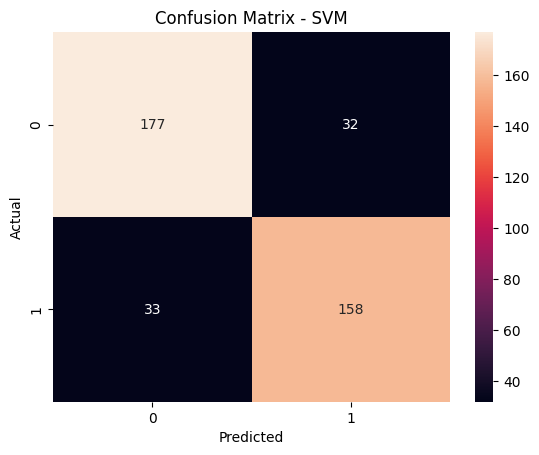

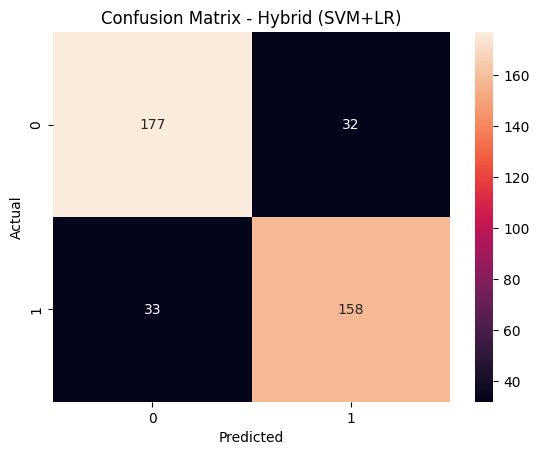

In [ ]:
import seaborn as sns

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
results_df = pd.DataFrame(results, index=[
    "Specificity", "Sensitivity", "Accuracy", "Precision",
    "FPR", "FNR", "NPV", "FDR", "F1 Score", "MCC"
]).T

print(results_df)

                     Specificity  Sensitivity  Accuracy  Precision      FPR  \
Naive Bayes              0.91866     0.664921    0.7975   0.881944  0.08134   
Logistic Regression      0.84689     0.821990    0.8350   0.830688  0.15311   
SVM                      0.84689     0.827225    0.8375   0.831579  0.15311   
Hybrid (SVM+LR)          0.84689     0.827225    0.8375   0.831579  0.15311   

                          FNR       NPV       FDR  F1 Score       MCC  
Naive Bayes          0.335079  0.750000  0.118056  0.758209  0.607282  
Logistic Regression  0.178010  0.838863  0.169312  0.826316  0.669215  
SVM                  0.172775  0.842857  0.168421  0.829396  0.674276  
Hybrid (SVM+LR)      0.172775  0.842857  0.168421  0.829396  0.674276  


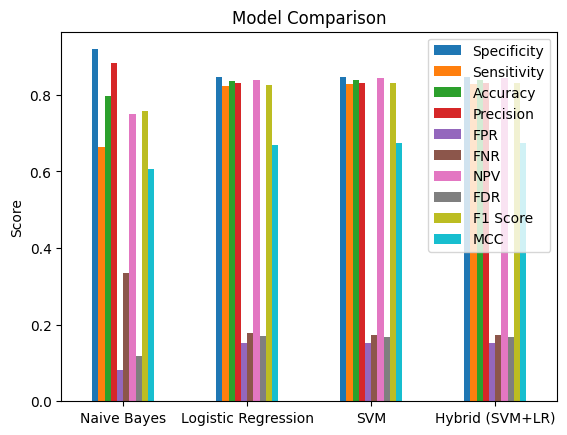

In [ ]:
results_df.plot(kind='bar')
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

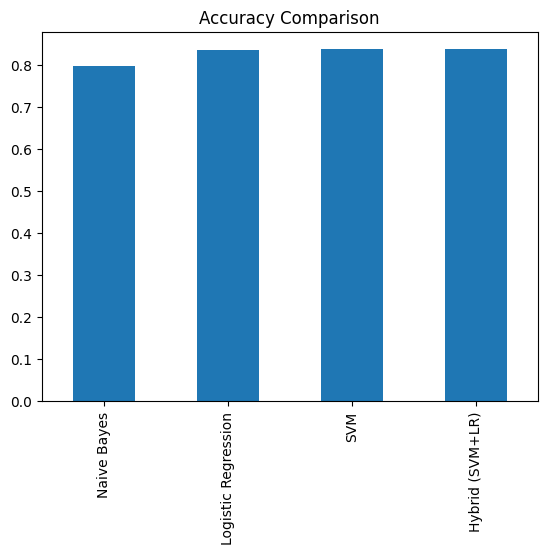

In [ ]:
results_df["Accuracy"].plot(kind='bar')
plt.title("Accuracy Comparison")
plt.show()

In [ ]:
sample = ["This movie was fantastic and amazing"]
sample_clean = [clean_text(s) for s in sample]
sample_tfidf = tfidf.transform(sample_clean)

prediction = models["SVM"].predict(sample_tfidf)

print("Prediction:", "Positive" if prediction[0] == 1 else "Negative")

Prediction: Positive
